<a href="https://colab.research.google.com/github/pendulumswings/pendulumswings.github.io/blob/main/scripts/chapter2/relative_power_oscillation_rotation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Comparison of Relative Power harmonic contribution for oscillations vs rotations of the simple pendulum.

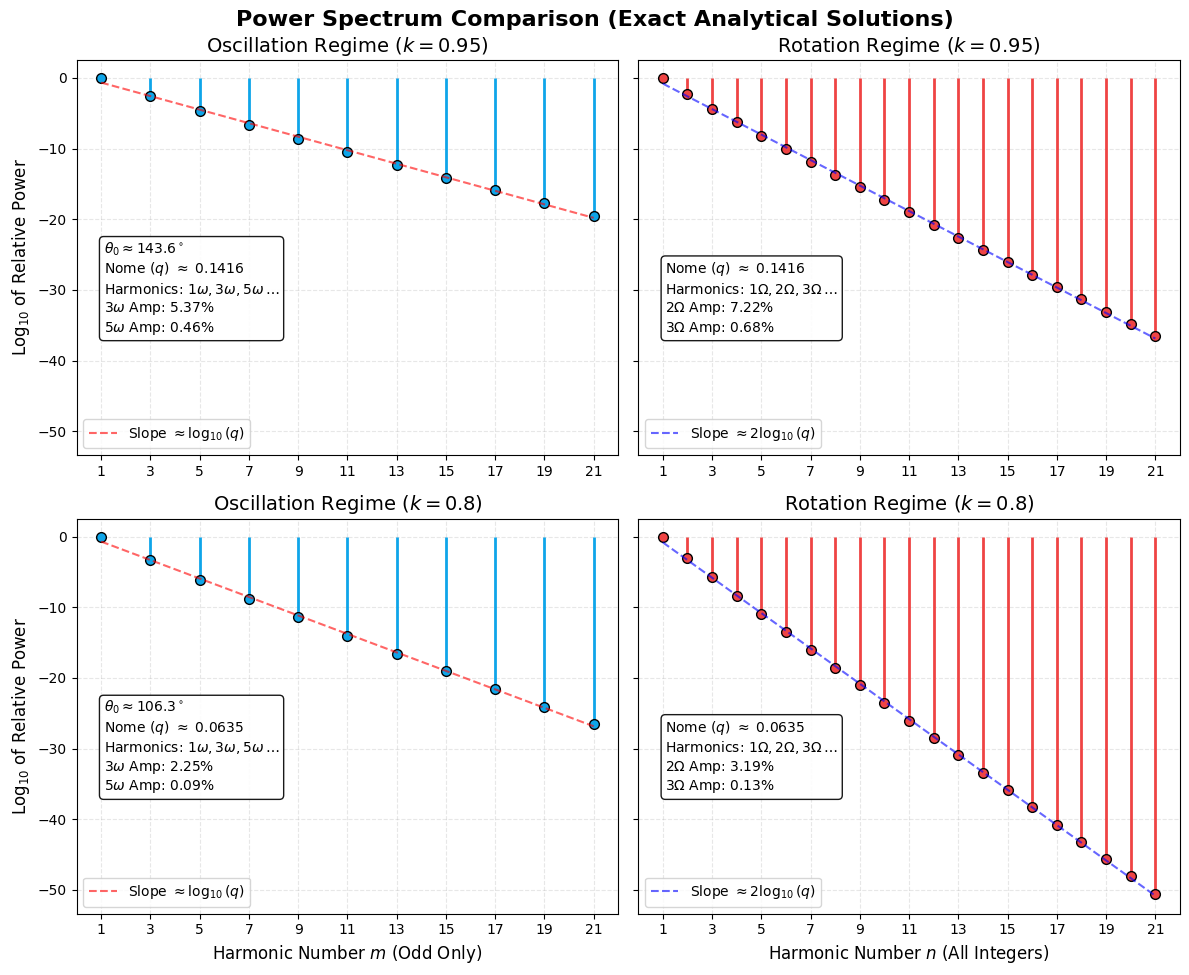

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ellipk

# --- 1. Define the Mathematical Baselines ---
# We use two different elliptic moduli (k) for comparison.
# k = 0.95 corresponds to a massive 143-degree drop.
# k = 0.80 corresponds to roughly a 106-degree drop.
k_values = [0.95, 0.80]

# Define the harmonic numbers
m_values = np.arange(1, 22, 2) # m = 1, 3, 5, 7 ... (Oscillation)
n_values = np.arange(1, 22, 1) # n = 1, 2, 3, 4 ... (Rotation)

# --- 2. Setup Plotting ---
fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharey=True)
fig.suptitle("Power Spectrum Comparison (Exact Analytical Solutions)", fontsize=16, fontweight='bold', y=0.97)

# --- 3. Compute and Plot for Each k ---
for i, k in enumerate(k_values):
    # Calculate the complete elliptic integrals and the Nome (q)
    K = ellipk(k**2)
    K_prime = ellipk(1.0 - k**2)
    q = np.exp(-np.pi * K_prime / K)

    # Calculate Exact Power for Oscillation
    P_rel_osc = (1.0 / m_values**2) * (q**(m_values - 1)) * ((1.0 + q) / (1.0 + q**m_values))**2
    log_P_osc = np.log10(P_rel_osc)

    # Calculate Exact Power for Rotation
    P_rel_rot = (1.0 / n_values**2) * (q**(2*n_values - 2)) * ((1.0 + q**2) / (1.0 + q**(2*n_values)))**2
    log_P_rot = np.log10(P_rel_rot)

    # ---------------------------------------------------
    # Subplot Column 0: Oscillation
    # ---------------------------------------------------
    ax1 = axs[i, 0]
    markerline1, stemlines1, baseline1 = ax1.stem(m_values, log_P_osc, basefmt=" ")
    plt.setp(markerline1, marker='o', markersize=7, color='#0ea5e9', markeredgecolor='black')
    plt.setp(stemlines1, color='#0ea5e9', linewidth=2)

    # Trendline for Oscillation
    trend_coef_osc = np.polyfit(m_values, log_P_osc, 1)
    trendline_osc = np.poly1d(trend_coef_osc)
    ax1.plot(m_values, trendline_osc(m_values), color='red', linestyle='--', alpha=0.6,
             label=f'Slope $\\approx \\log_{{10}}(q)$')

    ax1.set_title(f"Oscillation Regime ($k = {k}$)", fontsize=14)
    ax1.set_xticks(np.arange(1, 22, 2))
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(loc='lower left')

    # Only set x-labels on the bottom row
    if i == 1:
        ax1.set_xlabel("Harmonic Number $m$ (Odd Only)", fontsize=12)

    ax1.set_ylabel("Log$_{10}$ of Relative Power", fontsize=12)

    # Calculate amplitude percentages for oscillation
    A_osc = (1.0 / m_values) * (q**(m_values / 2.0)) / (1.0 + q**m_values)
    pct_osc_3w = (A_osc[1] / A_osc[0]) * 100
    pct_osc_5w = (A_osc[2] / A_osc[0]) * 100

    # Calculate physical release angle for the oscillation case
    theta_0_deg = np.degrees(2 * np.arcsin(k))

    # Add info box
    text_str_osc = (f"$\\theta_0 \\approx {theta_0_deg:.1f}^\\circ$\n"
                    f"Nome ($q$) $\\approx$ {q:.4f}\n"
                    f"Harmonics: $1\\omega, 3\\omega, 5\\omega\\dots$\n"
                    f"$3\\omega$ Amp: {pct_osc_3w:.2f}%\n"
                    f"$5\\omega$ Amp: {pct_osc_5w:.2f}%")
    ax1.text(0.05, 0.30, text_str_osc, transform=ax1.transAxes, fontsize=10,
             verticalalignment='bottom', horizontalalignment='left',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    # ---------------------------------------------------
    # Subplot Column 1: Rotation
    # ---------------------------------------------------
    ax2 = axs[i, 1]
    markerline2, stemlines2, baseline2 = ax2.stem(n_values, log_P_rot, basefmt=" ")
    plt.setp(markerline2, marker='o', markersize=7, color='#ef4444', markeredgecolor='black')
    plt.setp(stemlines2, color='#ef4444', linewidth=2)

    # Trendline for Rotation
    trend_coef_rot = np.polyfit(n_values, log_P_rot, 1)
    trendline_rot = np.poly1d(trend_coef_rot)
    ax2.plot(n_values, trendline_rot(n_values), color='blue', linestyle='--', alpha=0.6,
             label=f'Slope $\\approx 2\\log_{{10}}(q)$')

    ax2.set_title(f"Rotation Regime ($k = {k}$)", fontsize=14)
    ax2.set_xticks(np.arange(1, 22, 2))
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.legend(loc='lower left')

    # Only set x-labels on the bottom row
    if i == 1:
        ax2.set_xlabel("Harmonic Number $n$ (All Integers)", fontsize=12)

    # Calculate amplitude percentages for rotation
    A_rot = (1.0 / n_values) * (q**n_values) / (1.0 + q**(2*n_values))
    pct_rot_2w = (A_rot[1] / A_rot[0]) * 100
    pct_rot_3w = (A_rot[2] / A_rot[0]) * 100

    # Add info box
    text_str_rot = (f"Nome ($q$) $\\approx$ {q:.4f}\n"
                    f"Harmonics: $1\\Omega, 2\\Omega, 3\\Omega\\dots$\n"
                    f"$2\\Omega$ Amp: {pct_rot_2w:.2f}%\n"
                    f"$3\\Omega$ Amp: {pct_rot_3w:.2f}%")
    ax2.text(0.05, 0.30, text_str_rot, transform=ax2.transAxes, fontsize=10,
             verticalalignment='bottom', horizontalalignment='left',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()